In [48]:
import os

from physics.simulation import msq, sample
from physics.hzz import zpair, zz4l
from alice import dataset, model

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.colors import LogNorm
import hist

import torch
from torch.utils.data import TensorDataset
from lightning import Trainer

In [49]:
OUTPUT_DIR = 'jobs/alice/refactor-one-500k'
SCALER_FILE = 'scaler.pkl'
CHECKPOINT_DIR = 'checkpoints'
SAMPLE_DIR = '..'

CHECKPOINT = 'checkpoint-alice-epoch=44-val_loss=0.47.ckpt'

VERSION = 0
LIGHTNING_DIR = f'lightning_logs/version_{VERSION}'

COMPONENT_1 = msq.Component.SIG
COMPONENT_2 = msq.Component.BKG

SAMPLE_SIZE = 50000
BATCH_SIZE = 128
SEED = 42

In [50]:
xs = {
    msq.Component.SBI : 1.5569109,
    msq.Component.SIG : 0.15105108,
    msq.Component.INT : -0.22043824,
    msq.Component.BKG : 1.6270497
}

filenames = {
    msq.Component.SBI : 'ggZZ2e2m_sbi.csv',
    msq.Component.SIG : 'ggZZ2e2m_sig.csv',
    msq.Component.INT : 'ggZZ2e2m_int.csv',
    msq.Component.BKG : 'ggZZ2e2m_bkg.csv'
}

In [51]:
sample_background = sample.from_csv(cross_section=xs[COMPONENT_2], file_path=os.path.join(SAMPLE_DIR, filenames[COMPONENT_2]), n_rows=int(SAMPLE_SIZE*1.2))
        
msq_bkg_null = msq.MSQFilter('msq_bkg_sm', 0.0)
msq_bkg_nan = msq.MSQFilter('msq_bkg_sm', np.nan)

z_cand = zpair.ZPairCandidate(algorithm='leastsquare')
z_masses = zpair.ZPairMassWindow(z1=(70,115), z2=(70,115))
angles = zz4l.AngularVariables()
four_lepton_vars = zz4l.FourLeptonSystem()

sample_processed = sample_background.filter(msq_bkg_nan).filter(msq_bkg_null).calculate(z_cand).filter(z_masses).calculate(angles).calculate(four_lepton_vars)[:SAMPLE_SIZE]

features = ['cth_star', 'cth_1', 'cth_2', 'phi_1', 'phi', 'Z1_mass', 'Z2_mass', '4l_mass', '4l_rapidity']

# Get only required features
X = sample_processed.kinematics[features].to_numpy()

In [52]:
model_alice = model.ALICE.load_from_checkpoint(os.path.join(OUTPUT_DIR, CHECKPOINT_DIR, CHECKPOINT))

In [53]:
predictions = model_alice(torch.tensor(X, dtype=torch.float32)).detach().view(-1).numpy()
ratio_predicted = predictions/(1-predictions)

/tmp/ipykernel_5339/3944376228.py:2: RuntimeWarning: divide by zero encountered in divide
  ratio_predicted = predictions/(1-predictions)


In [54]:
inds = np.where(~(predictions==1.0))
predictions_filtered = predictions[inds]
ratio_predicted_filtered = predictions_filtered/(1-predictions_filtered)

sample_processed_filtered = sample_processed[inds]
X_filtered = X[inds]

In [70]:
r = sample_processed[np.where(predictions==1.0)].probabilities/sample_processed.reweight(COMPONENT_2, COMPONENT_1)[np.where(predictions==1.0)].probabilities
print(1/(1+r))
print(np.min(1/(1+r)), np.max(1/(1+r)))
print(np.min(sample_processed[np.where(predictions==1.0)].kinematics['4l_mass']))

16       0.079940
155      0.284855
177      0.163302
262      0.366688
452      0.548368
           ...   
50753    0.563632
51034    0.241985
51118    0.523930
51199    0.020924
51303    0.540652
Length: 451, dtype: float64
0.012836698935600622 0.6841353783170436
660.3839968727616


In [55]:
SIG_weights_predicted = sample_processed_filtered.weights.to_numpy() * ratio_predicted_filtered
SIG_weights_reweight = sample_processed_filtered.weights.to_numpy() * (sample_processed_filtered.reweight(COMPONENT_2, COMPONENT_1).probabilities.to_numpy()/sample_processed_filtered.probabilities.to_numpy())

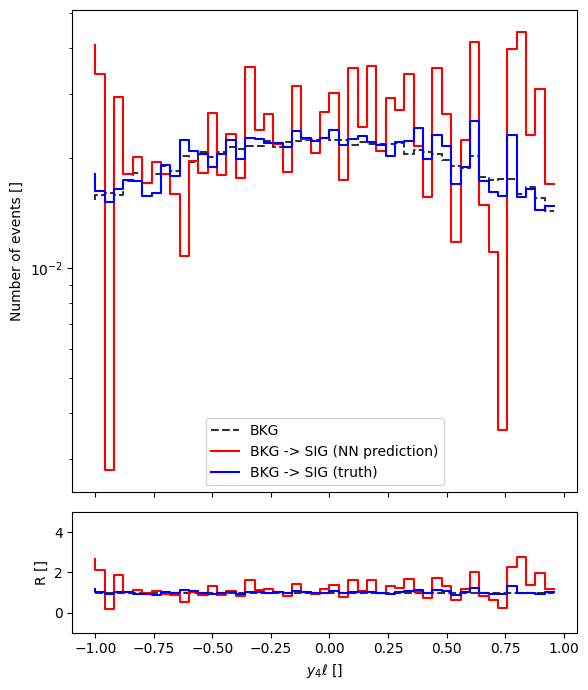

In [110]:
index = 8

kin_var = X_filtered[:,index]
label = ['$\mathrm{cos}(\\theta^*)$ []',
         '$\mathrm{cos}(\\theta_1)$ []',
         '$\mathrm{cos}(\\theta_2)$ []',
         '$\phi$ []',
         '$\phi_1$ []',
         '$m_{Z1}$ [GeV]',
         '$m_{Z2}$ [GeV]',
         '$m_{4\ell}$ [GeV]',
         '$y_4{\ell}$ []'][index]
bounds = [[-1,1],
          [-1,1],
          [-1,1],
          [-np.pi,np.pi],
          [-np.pi,np.pi],
          [70,115],
          [70,115],
          [180,660],
          [-1,1]][index]


BINS=50

hist_bkg, bins = np.histogram(kin_var, bins=BINS, range=bounds, weights=sample_processed_filtered.weights)
hist_pred, bins = np.histogram(kin_var, bins=BINS, range=bounds, weights=SIG_weights_predicted/np.sum(SIG_weights_predicted)*np.sum(SIG_weights_reweight))
hist_rew, bins = np.histogram(kin_var, bins=BINS, range=bounds, weights=SIG_weights_reweight)

fig, (ax1, ax2) = plt.subplots(2,1, gridspec_kw={'height_ratios': [4, 1]}, figsize=(6,7))

ax1.set_xticklabels([])

ax1.step(bins[:-1], hist_bkg, color='black', linestyle='--', label=u'BKG', alpha=0.8)
ax1.step(bins[:-1], hist_pred, color='r', label=u'BKG -> SIG (NN prediction)')
ax1.step(bins[:-1], hist_rew, color='b', label=u'BKG -> SIG (truth)')

ax1.set_ylabel('Number of events []')
ax1.set_yscale('log')
#ax1.set_ylim(0,10)

ax1.legend()

ax2.step(bins[:-1], hist_bkg/hist_bkg, color='black', linestyle='--', label=u'BKG', alpha=0.8)
ax2.step(bins[:-1], hist_pred/hist_bkg, color='r', label=u'BKG -> SIG (NN prediction)')
ax2.step(bins[:-1], hist_rew/hist_bkg, color='b', label=u'BKG -> SIG (truth)')
         
ax2.set_xlabel(label)
ax2.set_ylabel('R []')
#ax2.set_yscale('log')
ax2.set_ybound(-1.0,5.0)

fig.tight_layout()

plt.show()